# Next-quarter net interest income on the FR Y-9C panel

Research only. Independent research lab · Not affiliated with any employer or financial institution · Not investment advice.

**One target:** quarterly net interest income, BHCK4074, in **thousands of USD**. NII measures the difference between interest income and interest expense. The reference mapping was corrected: BHCK4107 − BHCK4073 = BHCK4074. The raw income statement is YTD: Q1 is unchanged; Q2–Q4 subtract the immediately prior quarter within the same RSSD and calendar year. Missing prior rows or values produce missing quarterly values, never imputation.

**Pre-specified test:** targets 2022Q1 through the latest available quarter; origins 2021Q4 through latest minus one. Roughly the first 3.5 years are reserved for burn-in. No parameters, windows, or methods are selected using test performance.

**Universe:** at every origin t, select the 50 largest BHCs by reported BHCK2170 assets at t (RSSD breaks ties). This rule also selects historical training rows at their own origins. No future membership is used. Evaluate all methods on the same intersection with target, current NII, and same-quarter-last-year NII observed. Report target/de-cumulation and history exclusions separately.

**Methods:** naive ŷ(t+1)=y(t); seasonal naive ŷ(t+1)=y(t−3); pooled expanding OLS g(s+1)=a+b1 g(s)+b4 g(s−3), where g(s)=log y(s)−log y(s−1). Training targets satisfy s+1≤t. Fit with numpy.linalg.lstsq, with an intercept and no tuning, regularization, weighting, or clipping. All required log inputs must be positive; otherwise the AR prediction falls back to naive and is counted. Historical membership can include exited institutions. MAE and RMSE use thousands USD; MAPE is mean absolute error divided by absolute actual NII, in percent (zero actuals excluded only from MAPE and counted).

**Timing limitation:** this is a report-quarter backtest using currently downloaded filings, not a real-time vintage or filing-release-date backtest. Revisions and reporting delays are not modeled; period-t filings are treated as available at the origin.

In [1]:
from pathlib import Path
import sys, json, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'tracks/y9c-panel/core_items.yaml').exists())
TRACK = ROOT / 'tracks/y9c-panel'
sys.path.insert(0, str(TRACK))
from y9c.panel import sanity
from y9c.forecast import evaluate, METHODS
PROCESSED = TRACK / 'data/processed'
RESULTS = ROOT / 'docs/tracks/y9c-panel/results'
FIGURES, TABLES = RESULTS / 'figures', RESULTS / 'tables'
FIGURES.mkdir(parents=True, exist_ok=True)
TABLES.mkdir(parents=True, exist_ok=True)
panel = pd.read_parquet(PROCESSED / 'panel_wide.parquet')
coverage = pd.read_csv(PROCESSED / 'coverage.csv', parse_dates=['report_date'])
vintage = json.loads((PROCESSED / 'vintage.json').read_text())
LABELS = {'naive': 'Naive', 'seasonal_naive': 'Seasonal naive', 'pooled_ar': 'Pooled panel AR', 'actual': 'Actual'}
COLORS = ['#0a2540', '#0a4080', '#5a7a9a', '#8daabe']
plt.rcParams.update({'axes.prop_cycle': plt.cycler(color=COLORS), 'figure.dpi': 130,
                     'axes.labelcolor': '#0a2540', 'text.color': '#0a2540',
                     'xtick.color': '#0a2540', 'ytick.color': '#0a2540',
                     'axes.edgecolor': '#5a7a9a', 'grid.color': '#8daabe',
                     'legend.fancybox': False, 'figure.facecolor': 'white', 'axes.facecolor': 'white'})
def save(fig, filename):
    for axis in fig.axes:
        axis.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:,.0f}'))
    fig.tight_layout()
    fig.savefig(FIGURES / filename, dpi=130, bbox_inches='tight')
    plt.show()
    plt.close(fig)

## Data checks and coverage
The sanity table prints JPMorgan (RSSD 1039502) quarterly and YTD NII. Its 2023–2025 quarters should be roughly 20–25 million thousand USD ($20–25 billion). For every complete JPMorgan calendar year, the four quarterly values must sum to Q4 YTD. The interest-income identity is checked across all comparable panel rows with a tolerance of one thousand USD.

Bulk files include records without consolidated Y-9C fields. The filer count below is the number with reported BHCK2170 total assets; all raw records remain in the cached panel. Coverage records both counts and the number of BHC-quarters losing quarterly NII due to a missing prior quarter/value.

The builder counts negative Q2–Q4 de-cumulations and separately the subset where every earlier quarter in the same year is observed and positive. These are diagnostic flags, not exclusions. BNP Paribas USA reported YTD NII of 1,910,303 in 2021Q3 and 192,866 in 2021Q4, giving −1,717,437 thousand USD de-cumulated quarterly NII. This is consistent with a within-year consolidation-scope change or restated YTD, but the flag does not establish the cause. Reported data are kept as-is.

JPMorgan RSSD 1039502; all amounts in thousands USD
report_date    nii_ytd      nii_q
 2023-03-31 20793000.0 20793000.0
 2023-06-30 42649000.0 21856000.0
 2023-09-30 65523000.0 22874000.0
 2023-12-31 89699000.0 24176000.0
 2024-03-31 23211000.0 23211000.0
 2024-06-30 46092000.0 22881000.0
 2024-09-30 69693000.0 23601000.0
 2024-12-31 93193000.0 23500000.0
 2025-03-31 23393000.0 23393000.0
 2025-06-30 46691000.0 23298000.0
 2025-09-30 70806000.0 24115000.0
 2025-12-31 95919000.0 25113000.0
 2026-03-31 25478000.0 25478000.0
 2026-06-30 51134000.0 25656000.0
JPM complete-year sums equal Q4 YTD: [{'year': 2018, 'quarterly_sum': 55396000.0, 'q4_ytd': 55396000.0}, {'year': 2019, 'quarterly_sum': 57595000.0, 'q4_ytd': 57595000.0}, {'year': 2020, 'quarterly_sum': 55000000.0, 'q4_ytd': 55000000.0}, {'year': 2021, 'quarterly_sum': 52539000.0, 'q4_ytd': 52539000.0}, {'year': 2022, 'quarterly_sum': 67129000.0, 'q4_ytd': 67129000.0}, {'year': 2023, 'quarterly_sum': 89699000.0, 'q4_ytd': 89699000.0}

,report_date,n_raw_records,n_bhcs,n_nii_ytd,n_nii_q,negative_nii_decumulations,negative_nii_after_positive,dropped_missing_prior_nii,dropped_missing_prior_any_flow,top50_asset_cutoff_thousands_usd
0,2018-03-31,775,656,656,656,0,0,0,0,37693158.0
1,2018-06-30,4507,650,650,647,1,0,3,3,38072954.0
2,2018-09-30,445,372,372,371,0,0,1,1,37730028.0
3,2018-12-31,4409,373,373,368,1,0,5,5,38543458.0
4,2019-03-31,436,364,363,363,0,0,0,0,40022893.0
5,2019-06-30,4336,363,362,358,1,0,4,4,42892358.0
6,2019-09-30,428,358,357,355,0,0,2,2,45139189.0
7,2019-12-31,4236,353,353,351,1,0,2,2,43785000.0
8,2020-03-31,420,353,353,353,0,0,0,0,48608892.0
9,2020-06-30,4155,350,350,349,1,0,1,1,48646800.0


NII de-cumulation drops: 49
Negative Q2–Q4 NII de-cumulations: 36
Of these, all prior quarters that year observed and positive: 6


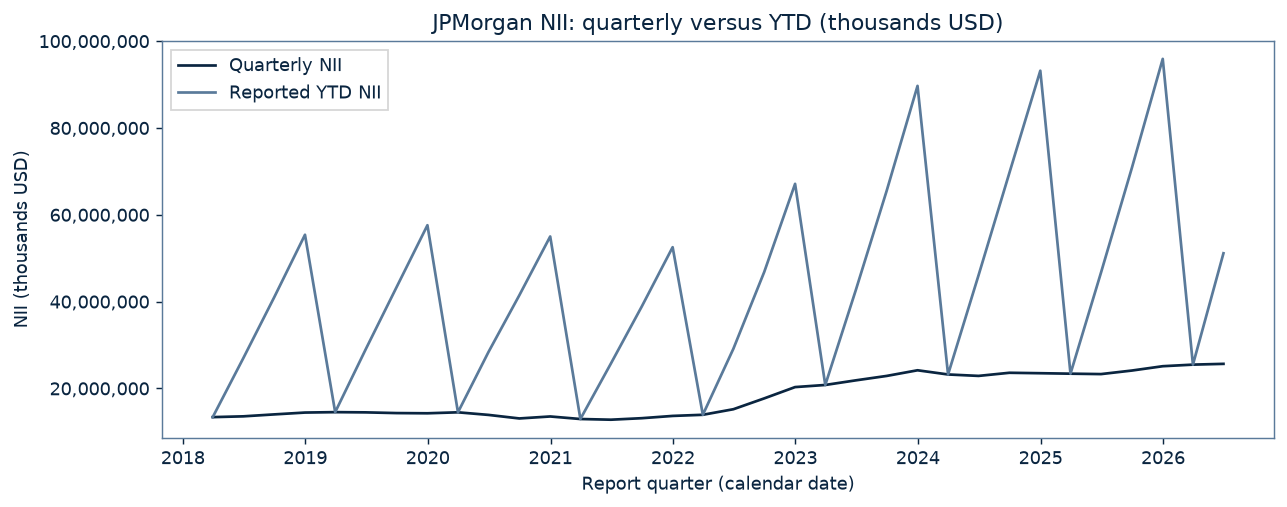

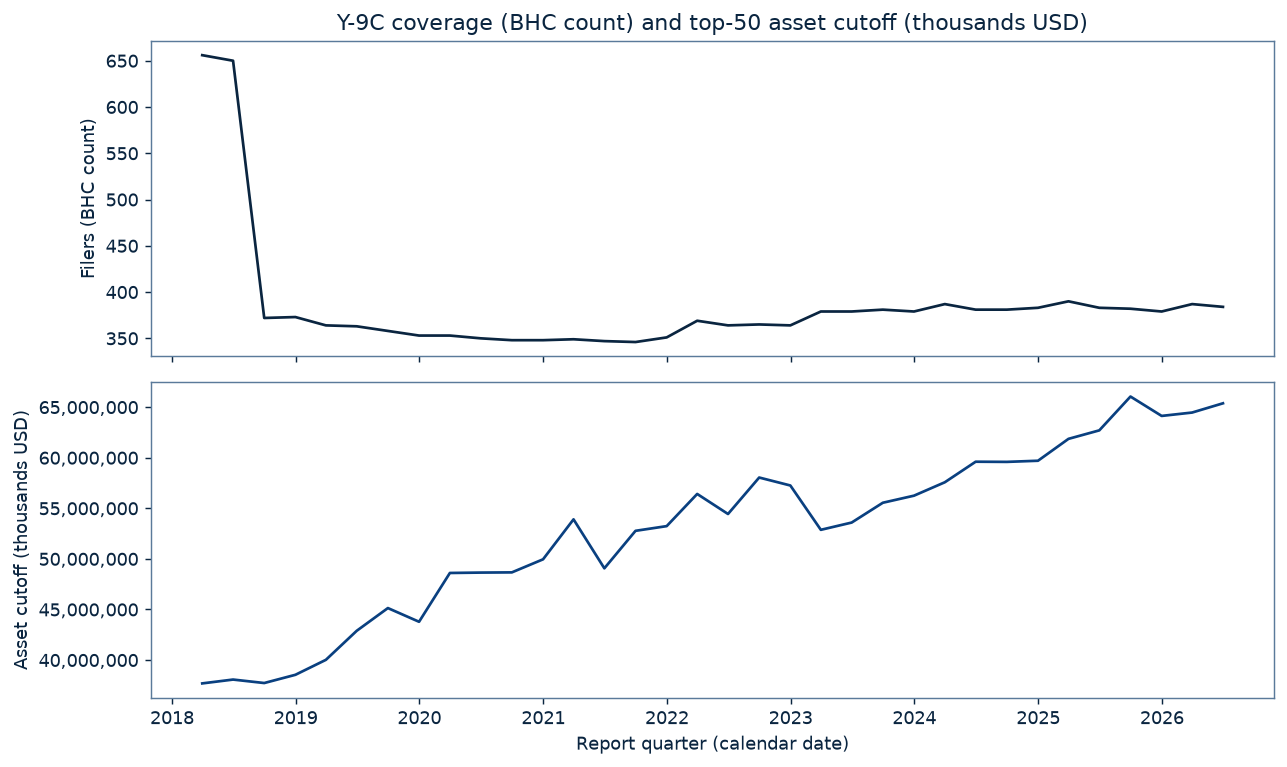

In [2]:
checks = sanity(panel)
display(coverage)
print('NII de-cumulation drops:', vintage['dropped_missing_prior_nii'])
print('Negative Q2–Q4 NII de-cumulations:', vintage['negative_nii_decumulations'])
print('Of these, all prior quarters that year observed and positive:', vintage['negative_nii_after_positive'])
jpm = panel[panel.rssd_id.eq(1039502)].sort_values('report_date')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(jpm.report_date, jpm.nii_q, color=COLORS[0], label='Quarterly NII')
ax.plot(jpm.report_date, jpm.nii_ytd, color=COLORS[2], label='Reported YTD NII')
ax.set(xlabel='Report quarter (calendar date)', ylabel='NII (thousands USD)', title='JPMorgan NII: quarterly versus YTD (thousands USD)')
ax.ticklabel_format(axis='y', style='plain'); ax.legend()
save(fig, 'jpm_nii.png')

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
axes[0].plot(coverage.report_date, coverage.n_bhcs, color=COLORS[0])
axes[0].set(ylabel='Filers (BHC count)', title='Y-9C coverage (BHC count) and top-50 asset cutoff (thousands USD)')
axes[1].plot(coverage.report_date, coverage.top50_asset_cutoff_thousands_usd, color=COLORS[1])
axes[1].set(xlabel='Report quarter (calendar date)', ylabel='Asset cutoff (thousands USD)')
axes[1].ticklabel_format(axis='y', style='plain')
save(fig, 'coverage.png')

## Fixed out-of-sample comparison
Errors are pooled equally across evaluated origin–BHC pairs. The aggregate figure sums over exactly those same evaluated BHCs each quarter, so its composition changes over time. Aggregate cancellation can hide institution-level forecast errors; the error tables measure those errors before aggregation. The final year may be partial.

**MdAPE (median absolute percentage error, %): supplementary, added after observing MAPE outliers; does not replace MAPE.** The same percentage-error cases and absolute-actual denominators are used, with zero actuals excluded. MAE, RMSE, MAPE and their winners remain the headline, pre-specified comparison. Supplementary MdAPE winners are reported separately overall and by year.

In [3]:
forecasts, overall, by_year, summary = evaluate(panel)
display(overall.rename(columns={'mdape': 'MdAPE (%, supplementary)'}))
display(by_year.rename(columns={'mdape': 'MdAPE (%, supplementary)'}))
print(json.dumps({k: v for k, v in summary.items() if k != 'origin_audit'}, indent=2))
display(pd.DataFrame(summary['origin_audit']))
for metric, winners in summary['winners'].items():
    print(f"Overall {metric.upper()} winner(s): {', '.join(winners)}")
print('Supplementary MdAPE winner(s):', ', '.join(LABELS[m] for m in summary['supplementary_mdape_winners']))
for year, winners in summary['supplementary_by_year_mdape_winners'].items():
    print(f"{year} supplementary MdAPE winner(s): {', '.join(LABELS[m] for m in winners)}")
# Only aggregate tables and metadata go into docs; no per-BHC exports.
for name, table in [('overall_errors', overall), ('by_year_errors', by_year)]:
    table.to_csv(TABLES / f'{name}.csv', index=False)
    (TABLES / f'{name}.json').write_text(table.to_json(orient='records', indent=2) + '\n')
(TABLES / 'test_design.json').write_text(json.dumps(summary, indent=2) + '\n')
_ = shutil.copyfile(PROCESSED / 'vintage.json', TABLES / 'vintage.json')

,method,n_forecasts,mae,rmse,mape,n_mape,"MdAPE (%, supplementary)"
0,naive,893,117823.276596,275791.186655,13.081779,893,3.453211
1,seasonal_naive,893,345028.732363,767683.569177,33.801965,893,10.740388
2,pooled_ar,893,134048.590651,303111.091962,14.020305,893,4.266864


,method,n_forecasts,mae,rmse,mape,n_mape,"MdAPE (%, supplementary)",target_year
0,naive,198,192429.671717,4.147459e+05,31.854456,198,8.073419,2022
1,seasonal_naive,198,458285.949495,9.170902e+05,79.483745,198,19.506256,2022
2,pooled_ar,198,219619.990514,4.677610e+05,33.566869,198,9.401950,2022
3,naive,199,104897.557789,2.135725e+05,8.634301,199,3.981403,2023
4,seasonal_naive,199,462895.623116,1.027732e+06,24.441270,199,15.750757,2023
5,pooled_ar,199,144051.345662,2.443110e+05,10.973478,199,6.260804,2023
6,naive,200,79489.700000,1.598633e+05,6.253886,200,2.618658,2024
7,seasonal_naive,200,198305.510000,3.594766e+05,15.642059,200,7.815362,2024
8,pooled_ar,200,94570.869188,2.027915e+05,6.479628,200,2.757762,2024
9,naive,198,110835.181818,2.940965e+05,10.253567,198,2.823025,2025


{
  "target": "BHCK4074 quarterly net interest income",
  "units": "thousands USD",
  "fixed_test_start": "2022Q1",
  "test_end": "2026Q2",
  "first_origin": "2021Q4",
  "last_origin": "2026Q1",
  "n_forecasts_per_method": 893,
  "n_target_quarters": 18,
  "selected_origin_bhc_pairs": 900,
  "dropped_target_missing": 6,
  "dropped_history": 1,
  "ar_fallbacks": 21,
  "zero_actuals_excluded_from_mape": 0,
  "nonpositive_actuals": 10,
  "supplementary_metric_note": "MdAPE (median absolute percentage error, %): supplementary, added after observing MAPE outliers; does not replace MAPE",
  "supplementary_mdape_winners": [
    "naive"
  ],
  "supplementary_by_year_mdape_winners": {
    "2022": [
      "naive"
    ],
    "2023": [
      "naive"
    ],
    "2024": [
      "naive"
    ],
    "2025": [
      "pooled_ar"
    ],
    "2026": [
      "naive"
    ]
  },
  "winners": {
    "mae": [
      "naive"
    ],
    "rmse": [
      "naive"
    ],
    "mape": [
      "naive"
    ]
  },
  "by_yea

,origin,target,selected,dropped_target_missing,dropped_history,evaluated,ar_fallbacks,training_rows,training_last_target
0,2021Q4,2022Q1,50,1,0,49,3,526,2021Q4
1,2022Q1,2022Q2,50,1,0,49,2,572,2022Q1
2,2022Q2,2022Q3,50,0,0,50,2,619,2022Q2
3,2022Q3,2022Q4,50,0,0,50,3,667,2022Q3
4,2022Q4,2023Q1,50,1,0,49,2,714,2022Q4
5,2023Q1,2023Q2,50,0,0,50,0,761,2023Q1
6,2023Q2,2023Q3,50,0,0,50,0,811,2023Q2
7,2023Q3,2023Q4,50,0,0,50,0,861,2023Q3
8,2023Q4,2024Q1,50,0,0,50,0,911,2023Q4
9,2024Q1,2024Q2,50,0,0,50,1,960,2024Q1


Overall MAE winner(s): naive
Overall RMSE winner(s): naive
Overall MAPE winner(s): naive
Supplementary MdAPE winner(s): Naive
2022 supplementary MdAPE winner(s): Naive
2023 supplementary MdAPE winner(s): Naive
2024 supplementary MdAPE winner(s): Naive
2025 supplementary MdAPE winner(s): Pooled panel AR
2026 supplementary MdAPE winner(s): Naive


## Supplementary MAPE outlier diagnostic
A few foreign-bank IHCs with near-zero or negative NII (including BNP Paribas USA, Mizuho Americas and Credit Suisse USA) drive the mean percentage error. BNP Paribas USA's 2022Q1 naive APE is about 3,350%. The table below shows the ten largest naive absolute percentage errors, without excluding them from any metric. Monetary columns are thousands USD; APE is percent. Names are taken from the target-quarter filing. This table is shown only in the notebook, not exported to docs/.

In [4]:
print('Nonpositive actual NII cases:', summary['nonpositive_actuals'], 'of', summary['n_forecasts_per_method'])
outliers = forecasts.copy()
outliers['ape_percent'] = ((outliers.naive - outliers.actual).abs()
                           / outliers.actual.abs().where(outliers.actual.ne(0)) * 100)
names = panel[['rssd_id', 'report_date', 'name']].copy()
names['target_quarter'] = names.report_date.dt.to_period('Q')
outliers = outliers.merge(names[['rssd_id', 'target_quarter', 'name']],
                          on=['rssd_id', 'target_quarter'], how='left', validate='many_to_one')
top_errors = outliers.nlargest(10, 'ape_percent')[['name', 'target_quarter', 'actual', 'naive', 'ape_percent']]
top_errors.columns = ['Name', 'Target quarter', 'Actual (thousands USD)', 'Naive forecast (thousands USD)', 'APE (%)']
display(top_errors.reset_index(drop=True).style.format({
    'Actual (thousands USD)': '{:,.0f}', 'Naive forecast (thousands USD)': '{:,.0f}', 'APE (%)': '{:,.3f}'}))

Nonpositive actual NII cases: 10 of 893


,Name,Target quarter,Actual (thousands USD),Naive forecast (thousands USD),APE (%)
0,"BNP PARIBAS USA, INC.",2022Q1,"52,841","-1,717,437","3,350.198"
1,MIZUHO AMERICAS LLC,2025Q1,"-5,000","-57,000","1,040.000"
2,"CREDIT SUISSE HOLDINGS (USA), INC.",2022Q1,"-5,659","37,984",771.214
3,MIZUHO AMERICAS LLC,2024Q1,"-23,000","38,000",265.217
4,"CREDIT SUISSE HOLDINGS (USA), INC.",2023Q1,"37,434","129,863",246.912
5,MIZUHO AMERICAS LLC,2023Q3,"31,000","85,000",174.194
6,MUFG AMERICAS HOLDINGS CORPORATION,2022Q4,"-345,637","125,428",136.289
7,"CREDIT SUISSE HOLDINGS (USA), INC.",2022Q4,"129,863","-17,563",113.524
8,MIZUHO AMERICAS LLC,2025Q3,"42,000","-4,000",109.524
9,MIZUHO AMERICAS LLC,2024Q4,"-57,000","-102,000",78.947


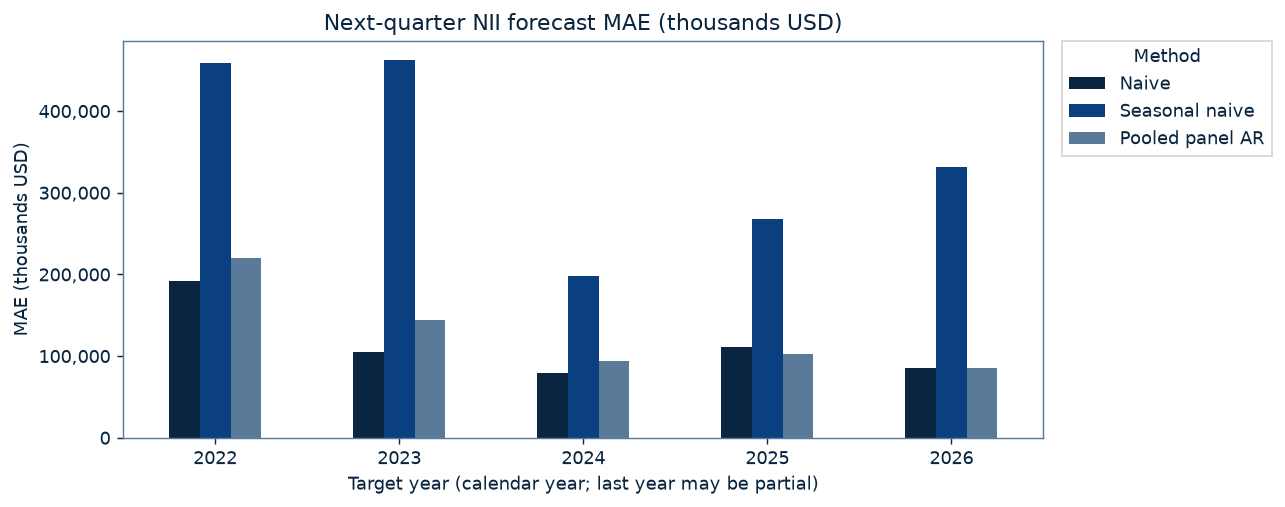

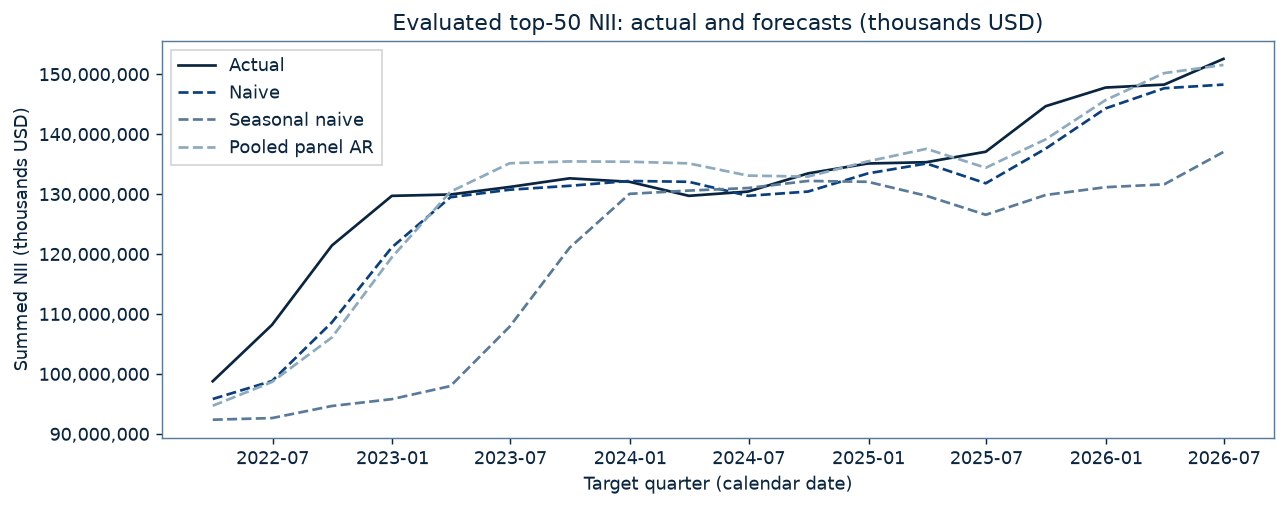

In [5]:
annual = by_year.pivot(index='target_year', columns='method', values='mae').reindex(columns=METHODS)
fig, ax = plt.subplots(figsize=(10, 4))
annual.rename(columns=LABELS).plot.bar(ax=ax, color=COLORS[:3], rot=0)
ax.set(xlabel='Target year (calendar year; last year may be partial)', ylabel='MAE (thousands USD)', title='Next-quarter NII forecast MAE (thousands USD)')
ax.legend(title='Method', loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0); ax.ticklabel_format(axis='y', style='plain')
save(fig, 'annual_mae.png')

aggregate = forecasts.groupby('target_quarter')[['actual', *METHODS]].sum()
x = aggregate.index.to_timestamp(how='end').normalize()
fig, ax = plt.subplots(figsize=(10, 4))
for i, column in enumerate(aggregate):
    ax.plot(x, aggregate[column], color=COLORS[i], label=LABELS[column], linestyle='-' if i == 0 else '--')
ax.set(xlabel='Target quarter (calendar date)', ylabel='Summed NII (thousands USD)', title='Evaluated top-50 NII: actual and forecasts (thousands USD)')
ax.ticklabel_format(axis='y', style='plain'); ax.legend()
save(fig, 'aggregate_nii.png')

## Interpretation and limitations
The printed tables and winners are the result of the fixed specification, including any baseline wins; the models, universe, test window and headline metrics remain unchanged. Supplementary MdAPE was added after observing MAPE outliers and does not replace MAPE. Dollar errors emphasize large institutions; MAPE can be unstable around zero or sign changes, and negative NII cannot enter log-growth training.

The panel follows **RSSD IDs as reported**, without pro-forma merger adjustment. Entrants appear when they start filing and need sufficient history for evaluation. Exiters retain their historical training observations but are not forecast after their last filing; an origin selected just before exit has no evaluable next-quarter target and is counted as a drop. Acquirers' NII jumps remain and can create large forecast errors. Missing predecessor quarters are never bridged or imputed.

The **2018Q3 reporting threshold change from $1 billion to $3 billion** mainly affects small filers and explains much of the coverage break. Foreign-bank intermediate holding companies file Y-9C and may enter the top 50. Parent and subsidiary filers are not consolidated across RSSD IDs, so the aggregate is a sample sum rather than a non-overlapping US banking-sector total. All monetary quantities are **thousands of USD**. Downloads can contain later filing revisions, and cached files are reused: metadata records exactly which bytes were used and when first obtained/seen.

To reproduce from the repository root: `make y9c`. Raw files and institution-level data remain in the ignored runtime cache. Only figures, aggregate errors, test-design metadata and vintage metadata go to the results page; the ten-case diagnostic remains in this notebook. Research only; not investment advice.

Negative de-cumulation can reflect a within-year consolidation-scope change or restated YTD, as illustrated by the BNP Paribas USA 2021Q3–Q4 figures above. Counts are reported in the coverage output and vintage metadata, and no values are corrected or removed.